**Assignment 4 — Integrated Case Study: Retail Analytics and Predictive Insights**

**Context**                 
You are a data analyst at a retail firm, SmartCart Analytics Pvt Ltd, which sells various product categories online.
Your manager wants you to analyze the firm’s transactional dataset and derive actionable insights.
You will apply Python fundamentals, visualization, mathematical modeling, and statistical analysis — integrating concepts learned in Assignments 1–3.

**Dataset Description (Synthetic Simulation)**

                  
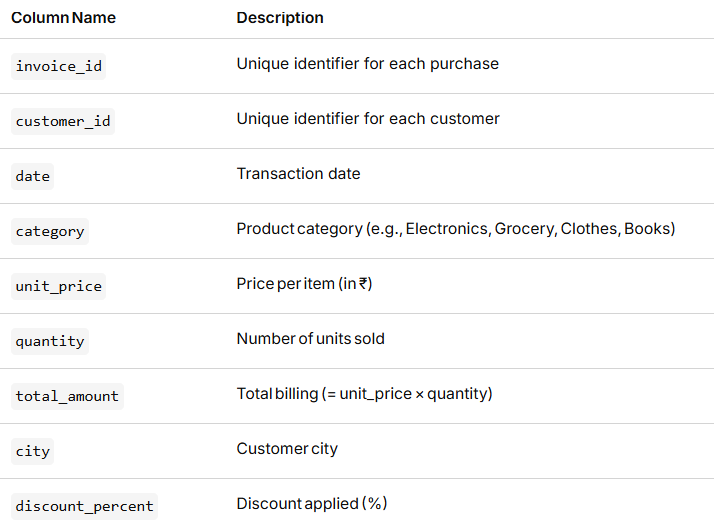

Q1 – Setup and Data Generation                          
Write a Python function to generate a DataFrame simulating 5,000 transactions over 60 days.
Use random seeds for reproducibility. Display the head of the simulated dataset.

In [ ]:
from random import seed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.ma.core import maximum_fill_value
from pyparsing import And

np.random.seed(123)
categories = ["Electronics", "Grocery", "Books", "Clothes"]
city = ['Bengaluru', 'Chennai', 'Hyderabad', 'Pune', 'Mumbai', 'Delhi', 'Gurgaon']

s = 5000

df = pd.DataFrame({
    "invoice_id": np.random.randint(1000, 6000, size=s),
    "customer_id": np.random.randint(2000, 7000, size=s),
    "date": np.random.choice(
        pd.date_range("2025-01-01", "2025-03-02"),
        size=s
    ),
    "category": np.random.choice(categories, size=s),
    "unit_price": np.random.randint(10, 100, size=s),
    "quantity": np.random.randint(1, 20, size=s),
    "city": np.random.choice(city, size=s),
    "discount": np.random.randint(1, 5, size=s),
})

df['total_amount'] = df['quantity'] * df['unit_price']
df.head()

,invoice_id,customer_id,date,category,unit_price,quantity,city,discount,total_amount
0,4582,5772,2025-01-26,Books,12,12,Gurgaon,3,144
1,4454,4409,2025-01-06,Grocery,56,1,Pune,1,56
2,2346,5823,2025-02-24,Grocery,11,18,Pune,3,198
3,5060,2992,2025-01-24,Electronics,99,4,Mumbai,2,396
4,2593,2554,2025-01-01,Grocery,16,9,Chennai,1,144


**Q2 – Feature Derivation**                                  
Add computed columns:

Final billing (final_amount = total_amount × (1 – discount_percent/100))                  
Day of Week (from date)                                               
Display summary statistics using NumPy.

In [ ]:
df['final_amount'] = df['total_amount'] * ( 1 - df['discount']/100 )
df["day_of_week"] = df["date"].dt.day_name()


print("Mean unit price:", np.mean(df["unit_price"]))
print("Mean quantity:", np.mean(df["quantity"]))
print("Mean final amount:", np.mean(df["final_amount"]))

print("Std unit price:", np.std(df["unit_price"]))
print("Max quantity:", np.max(df["quantity"]))
print("Min quantity:", np.min(df["quantity"]))

df.head()

Mean unit price: 54.6496
Mean quantity: 10.0688
Mean final amount: 539.609862
Std unit price: 25.743030510023484
Max quantity: 19
Min quantity: 1


,invoice_id,customer_id,date,category,unit_price,quantity,city,discount,total_amount,final_amount,day_of_week
0,4582,5772,2025-01-26,Books,12,12,Gurgaon,3,144,139.68,Sunday
1,4454,4409,2025-01-06,Grocery,56,1,Pune,1,56,55.44,Monday
2,2346,5823,2025-02-24,Grocery,11,18,Pune,3,198,192.06,Monday
3,5060,2992,2025-01-24,Electronics,99,4,Mumbai,2,396,388.08,Friday
4,2593,2554,2025-01-01,Grocery,16,9,Chennai,1,144,142.56,Wednesday


**Q3 – Exploratory Analysis**                                     
Plot the average final_amount across different product categories using Matplotlib.                                           
Customize the plot with color, labels, and a legend.

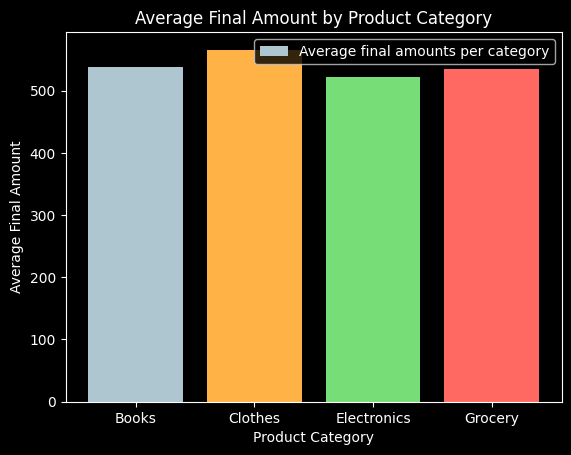

In [ ]:
avg_category_sales = df.groupby('category')['final_amount'].mean()
avg_category_sales.head()
colors = ['#AEC6CF', '#FFB347', '#77DD77', '#FF6961', '#CFCFC4', '#FDFD96', '#CBAACB', '#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#EDC948', '#B07AA1']
plt.bar(avg_category_sales.index, avg_category_sales.values, color=colors)

plt.xlabel("Product Category")
plt.ylabel("Average Final Amount")
plt.title("Average Final Amount by Product Category")

plt.legend(["Average final amounts per category"])
plt.show()

**Q4 – Customer Segmentation**                                            
Use list comprehensions and functions to classify customers:

High‑value (> 90th percentile of spend)                           
Medium (50th–90th percentile)                                
Low (< 50th percentile)                               
Print the count in each segment and display results.                       

In [ ]:
high_value_threshold = df["final_amount"].quantile(0.90)
high_value_customers = len(df[df['final_amount'] > high_value_threshold])

medium_value_threshold = df['final_amount'].quantile(0.50)
medium_value_customers= len(df[(df['final_amount'] >= medium_value_threshold) & (df['final_amount'] <= high_value_threshold)])

low_value_customers = len(df[df['final_amount'] < medium_value_threshold])

print('High Value Customers: {}'.format(high_value_customers))
print('Medium value customers: {}'.format(medium_value_customers))
print('Low value customers: {}'.format(low_value_customers))


High Value Customers: 499
Medium value customers: 2001
Low value customers: 2500


**Q5 – City‑wise Performance Visualization**
Create a bar plot of total sales per city.                                  
Mark the city with maximum sales using annotations and highlighting.

Text(0, 0.5, 'Sales per city')

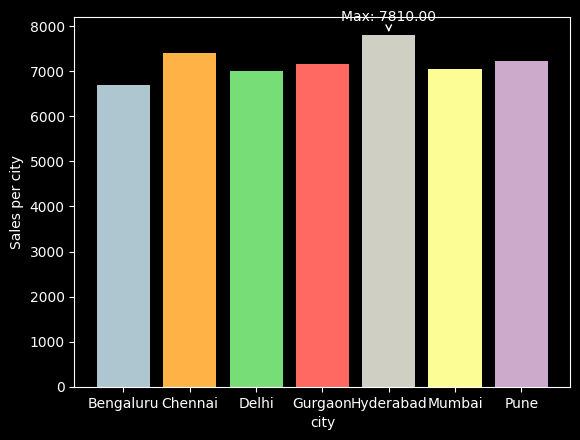

In [ ]:
df_sales_per_city = df.groupby('city')['quantity'].sum()
df_sales_per_city.head()
max_city = df_sales_per_city.idxmax()
max_value = df_sales_per_city.max()


plt.bar(df_sales_per_city.index, df_sales_per_city.values, color=colors)
plt.annotate(
    f"Max: {max_value:.2f}",
    xy=(max_city, max_value),
    xytext=(0,10),
    textcoords="offset points",
    ha='center',
    arrowprops=dict(arrowstyle="->")
)


plt.xlabel('city')
plt.ylabel('Sales per city')

(**Q6 – Revenue Trend Analysis**
Compute and plot daily total revenue (final_amount sum per day).                     
Use a line plot, annotate mean revenue, and interpret the growth trend.

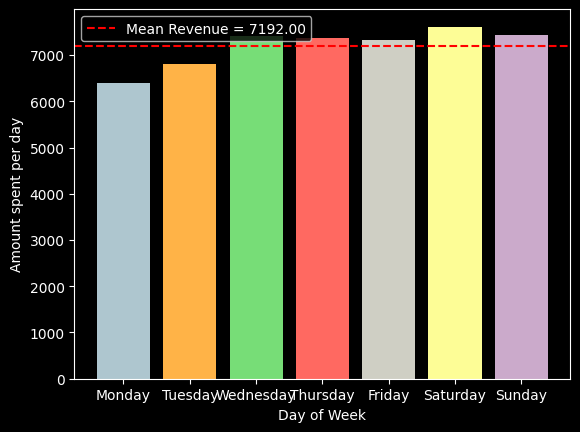

In [ ]:
df_sales_per_day = df.groupby('day_of_week')['quantity'].sum()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
df_sales_per_day = df_sales_per_day.reindex(day_order)

max_day = df_sales_per_day.idxmax()
max_day_value = df_sales_per_day.max()

mean_revenue = df_sales_per_day.mean()

plt.bar(df_sales_per_day.index, df_sales_per_day.values, color=colors)
plt.axhline(mean_revenue, color="red", linestyle="--", label=f"Mean Revenue = {mean_revenue:.2f}")
plt.xlabel("Day of Week")
plt.ylabel('Amount spent per day')
plt.legend()


**Q7 – Discount Impact Analysis**                              
Plot a scatter diagram between discount_percent and final_amount.                        
Compute their Pearson correlation coefficient using NumPy.                   
Discuss whether discounts help boost sales value.

-0.005443573233177788


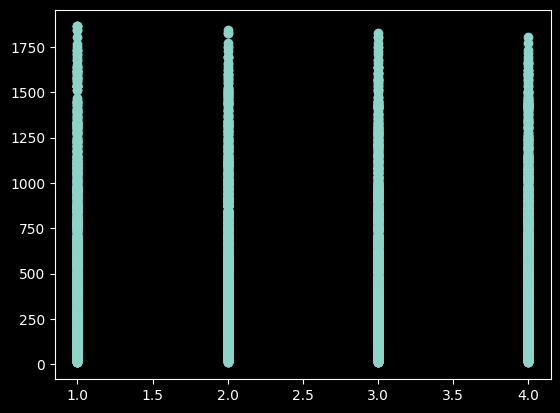

In [ ]:
plt.scatter(df['discount'], df['final_amount'])
coeff = np.corrcoef(df['discount'], df['final_amount'])[0, 1]
print(coeff)

**Q8 – Random Sampling and Central Limit Concept**          
Use the final_amount column created earlier.

Write a Python function that randomly samples 50 transactions from the dataset.
Repeat this sampling process 1,000 times and store the mean of each sample in a list.
Plot a histogram of the sample means (using Matplotlib).
Compute and display the mean and standard deviation of these sample means.
Comment on whether the distribution appears approximately normal (as suggested by the Central Limit Theorem).        

Mean of sample means: 541.8414468000007
Standard deviation: 59.17693815598277
The histogram of the sample means shows a bell-shaped distribution centered around approximately 539.77. This suggests that the distribution of the sample means is approximately normal.


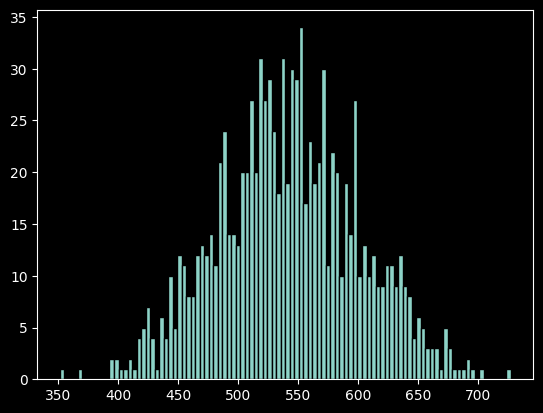

In [ ]:
mean_list = []
def sampling():
    rand_50_df = df.sample(n=50)
    mean = rand_50_df['final_amount'].mean()
    mean_list.append(mean)


for i in range(1000):
    sampling()

plt.hist(mean_list, bins=100, edgecolor='black')
mean_of_sample_means = sum(mean_list)/len(mean_list)
print('Mean of sample means: {}'. format(mean_of_sample_means))
print('Standard deviation: {}'.format(np.std(mean_list)))
print('The histogram of the sample means shows a bell-shaped distribution centered around approximately 539.77. This suggests that the distribution of the sample means is approximately normal.')

**Q9 – Customer Retention Modeling**                                 
Assume retention probability of customers follows a binomial distribution with p = 0.6.                                          
Simulate 100 customers for 5 periods.                           
Plot the distribution of number of retained customers using a histogram and overlay PDF.

Customers retained in each period:[49 64 52 50 61]


(array([0.13333333, 0.06666667, 0.        , 0.        , 0.13333333]),
 array([49., 52., 55., 58., 61., 64.]),
 <BarContainer object of 5 artists>)

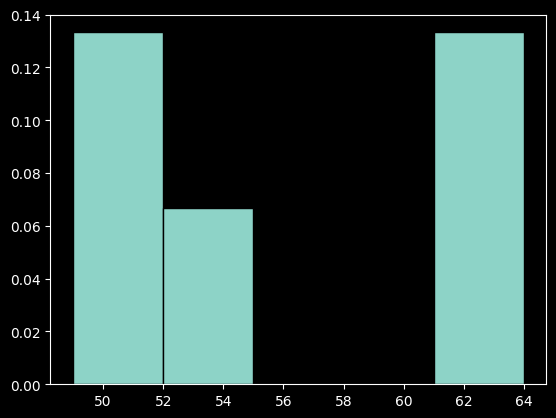

In [ ]:
customers = 100
periods = 5
p = 0.6
retention_probability = np.random.binomial(customers, p, size=periods)
print("Customers retained in each period:{}".format(retention_probability))
plt.hist(retention_probability, bins=5, edgecolor='black', density=True)

**Q10 – Insights Report**                                    
Summarize major insights from Tasks Q3–Q9.                                             
Write a function that prints these insights as a formatted report (e.g., markdown tables or console output).                                            
Include brief business recommendations.